Using device: cuda
Tesla T4
Total classes: 101
Test entries: 25250
Test entries used: 25250

Number of validation samples: 25250
Number of classes: 101

LOADING MODEL FROM CHECKPOINT

Checkpoint Information:
  Epoch: 21
  Train Loss: 0.4243
  Train Accuracy: 88.53%
  Validation Loss: 0.5150
  Validation Accuracy: 85.71%

EVALUATING MODEL ON TEST SET

Running inference on test set...
  Processed 2560/25250 samples...
  Processed 5120/25250 samples...
  Processed 7680/25250 samples...
  Processed 10240/25250 samples...
  Processed 12800/25250 samples...
  Processed 15360/25250 samples...
  Processed 17920/25250 samples...
  Processed 20480/25250 samples...
  Processed 23040/25250 samples...

OVERALL METRICS

Overall Test Accuracy: 85.73%
Total Test Samples: 25250
Correctly Classified: 21646
Incorrectly Classified: 3604

TOP-K ACCURACY
Top-1 Accuracy: 85.73%
Top-3 Accuracy: 94.94%
Top-5 Accuracy: 97.06%
Top-10 Accuracy: 98.74%

PER-CLASS PERFORMANCE

 Top 15 Best Performing Classes:
-----

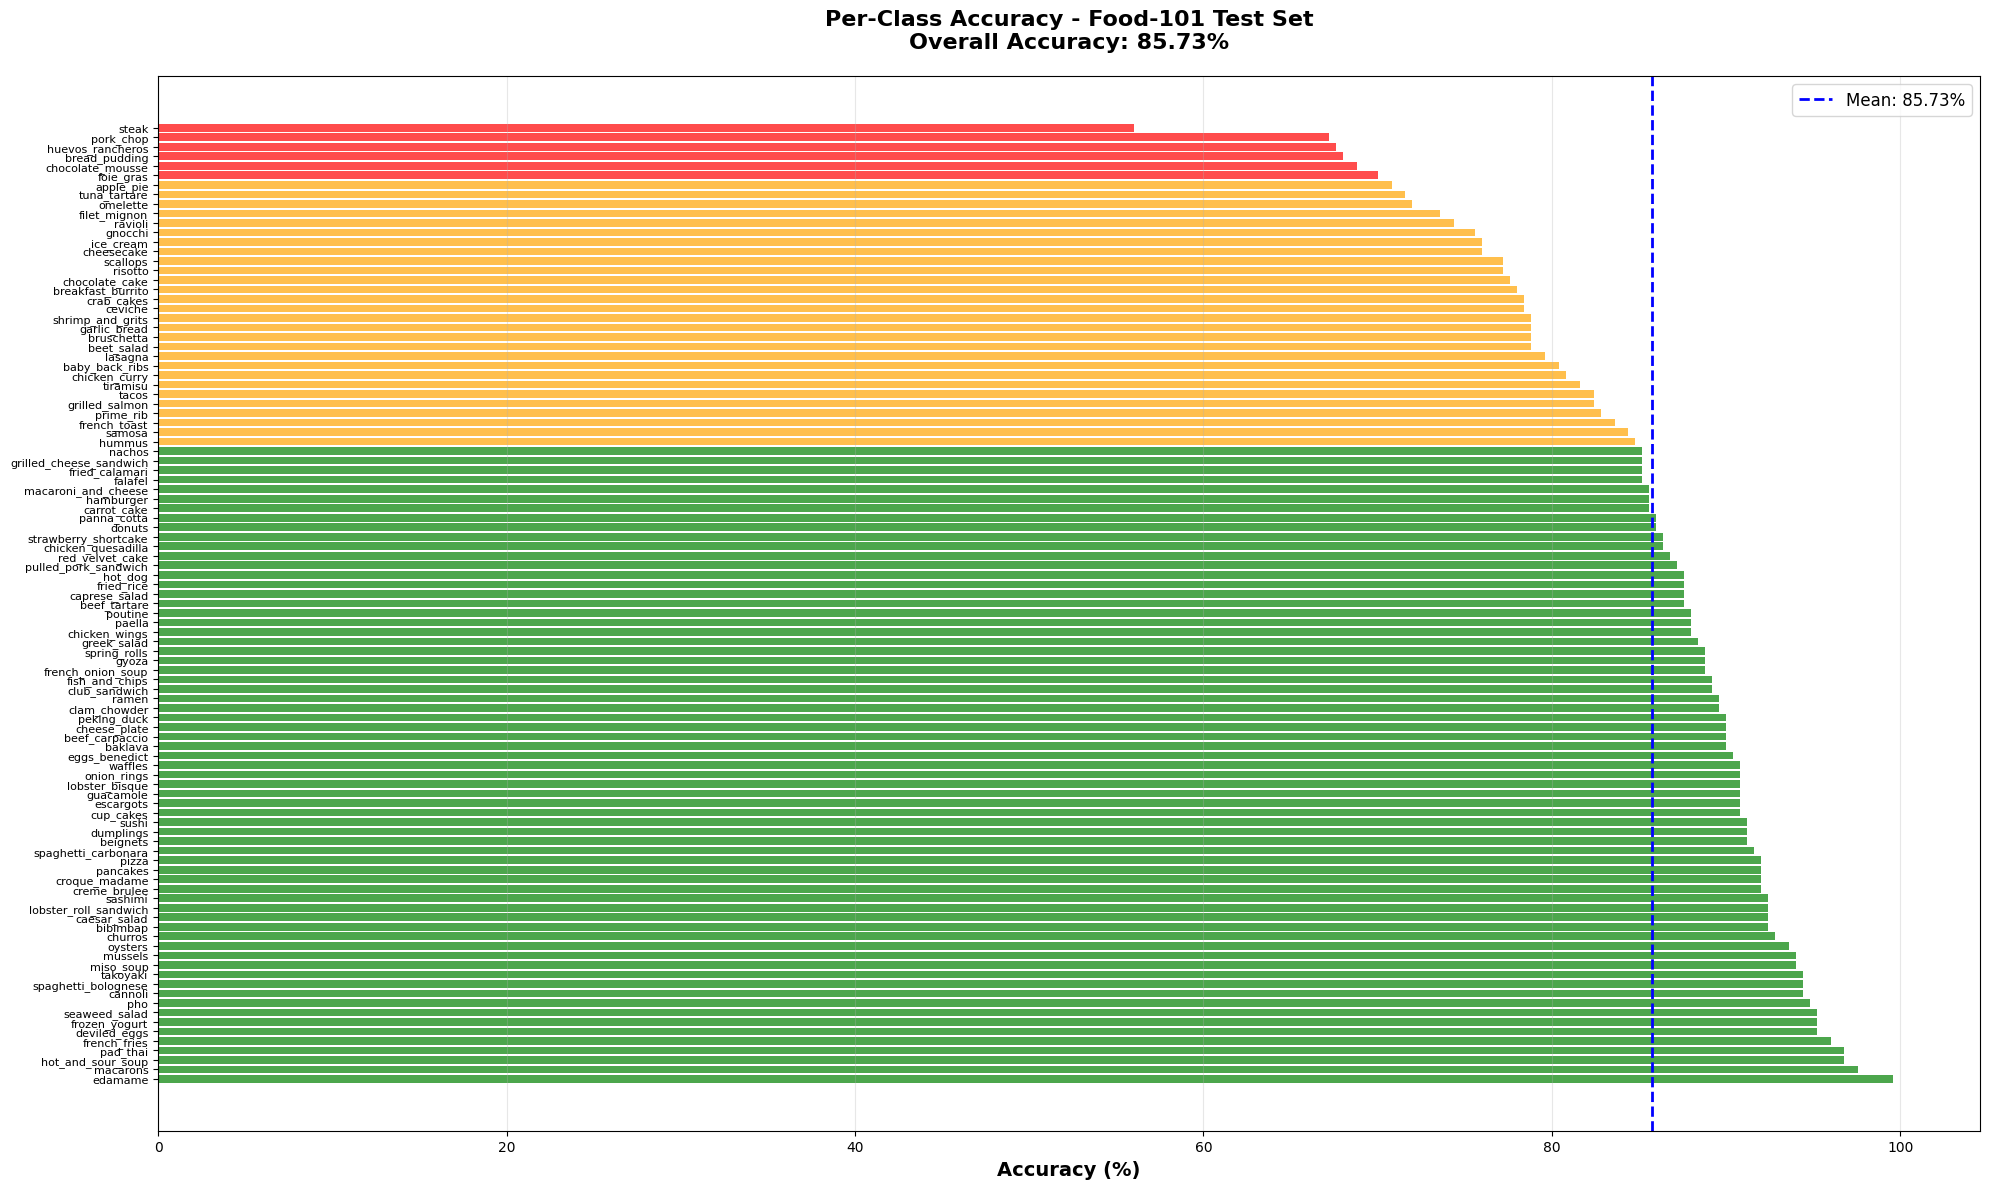

Per-class accuracy plot saved to: /kaggle/working/per_class_accuracy.png


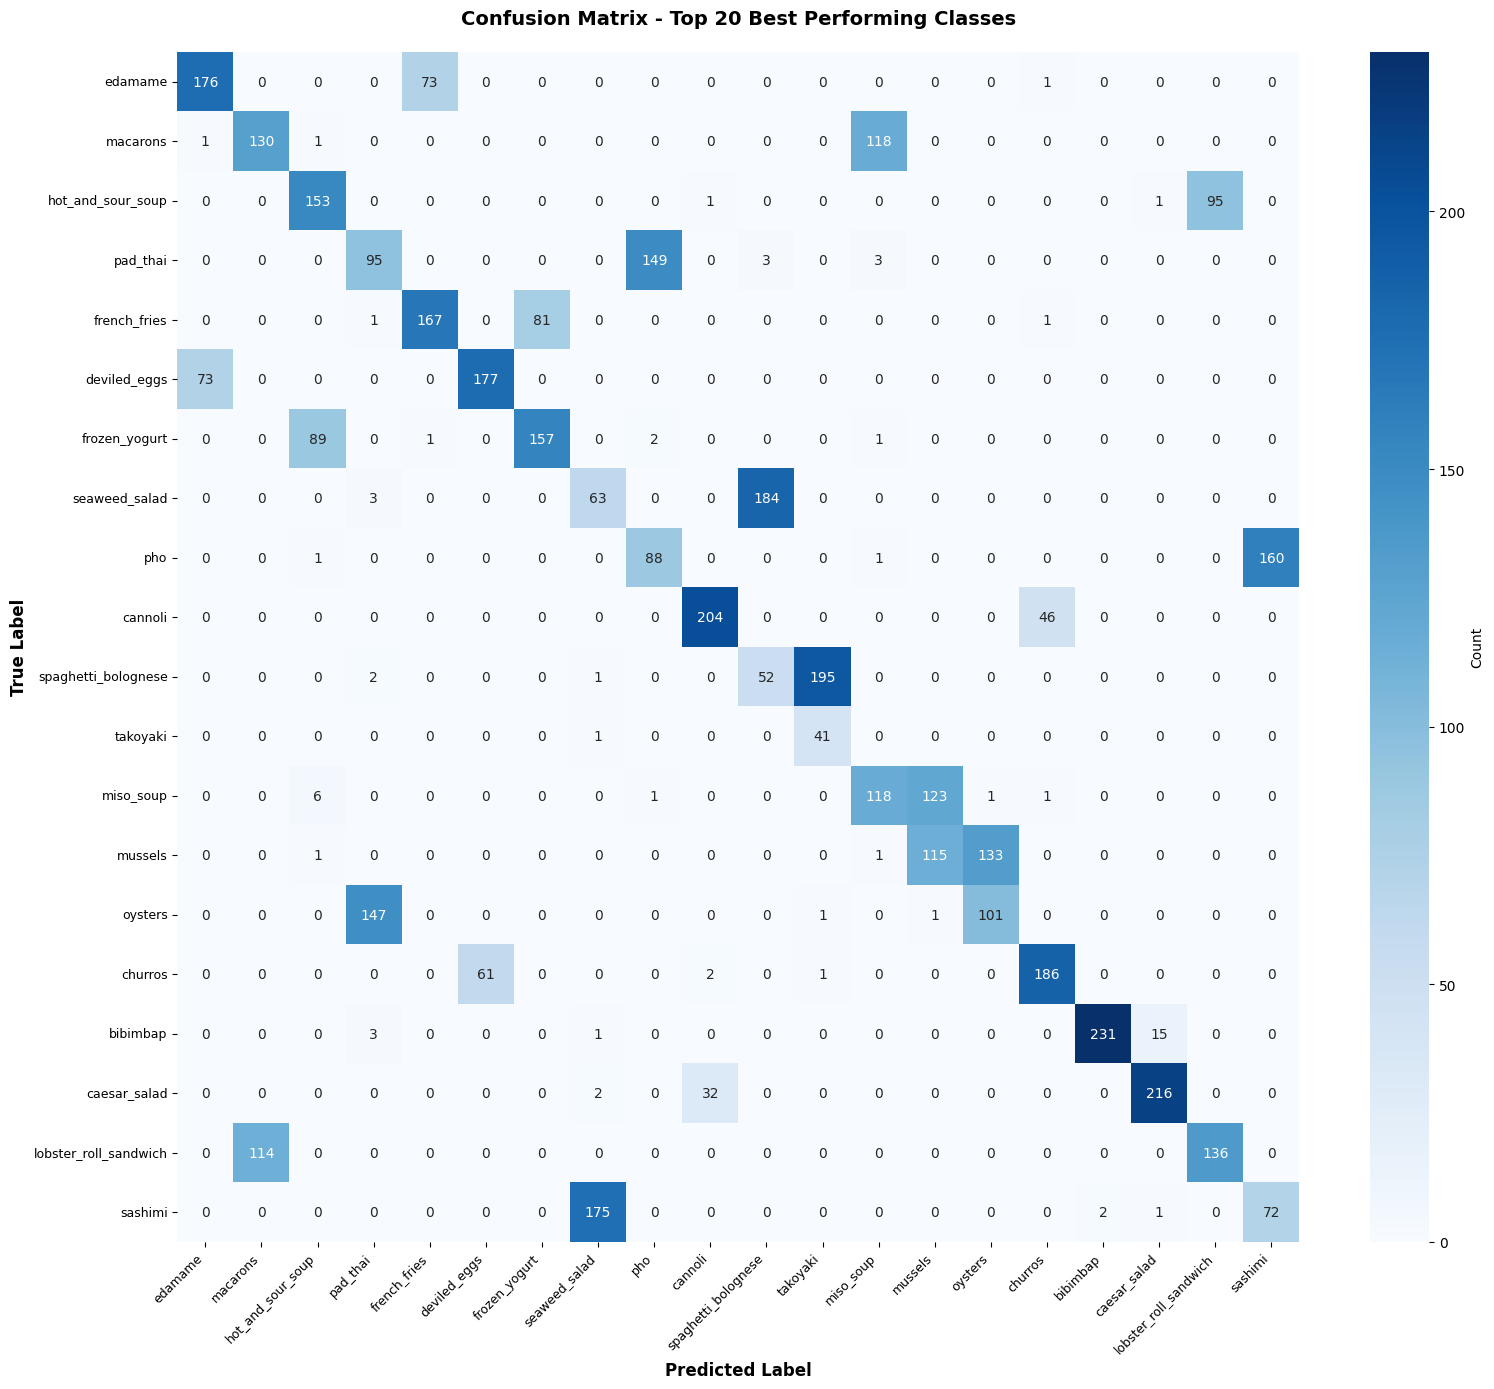

✓ Confusion matrix saved to: /kaggle/working/confusion_matrix_top20.png


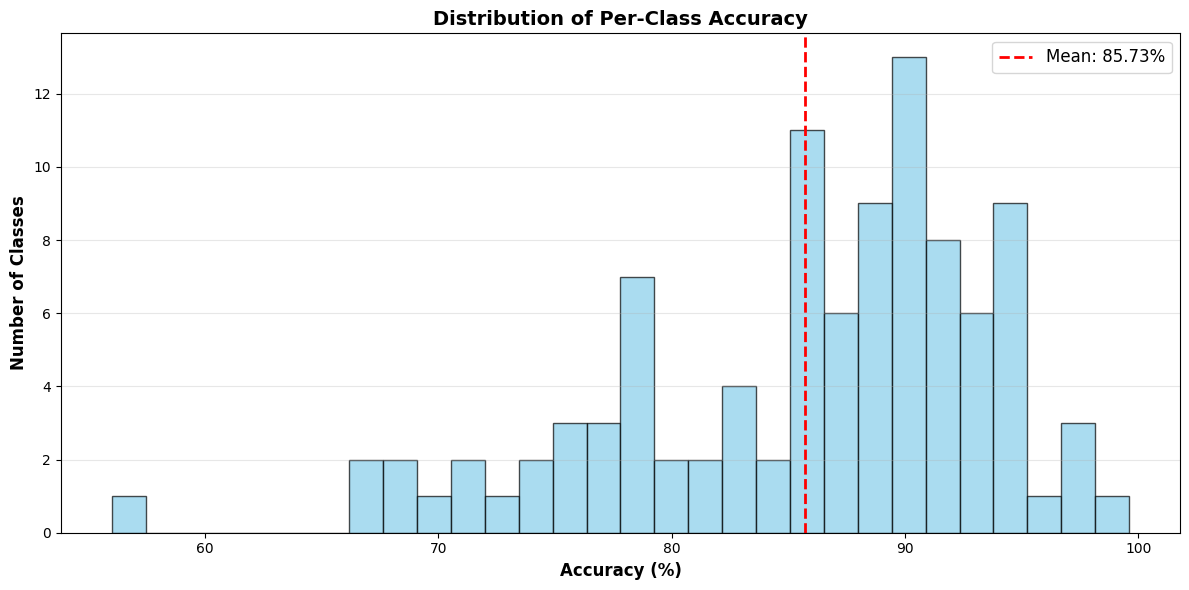

✓ Accuracy distribution plot saved to: /kaggle/working/accuracy_distribution.png

SUMMARY STATISTICS

Accuracy Statistics:
  Mean:   85.73%
  Median: 87.60%
  Std:    8.11%
  Min:    56.00% (steak)
  Max:    99.60% (edamame)

Classes by Performance:
  Excellent (≥90%): 39 classes
  Good (80-90%):    37 classes
  Fair (70-80%):    20 classes
  Poor (<70%):      5 classes

EVALUATION COMPLETE!


In [4]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.environ["WANDB_DISABLED"] = "true"

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# ============================================================
# PATHS CONFIGURATION
# ============================================================
FOOD101_ROOT = "/kaggle/input/dataset-for-nutridish-project/Model_Training/datasets/food101/"
IMAGES_DIR = os.path.join(FOOD101_ROOT, "images")
META_DIR = os.path.join(FOOD101_ROOT, "meta")

# Checkpoint path
CHECKPOINT_PATH = "/kaggle/input/notebookce86db1eb1/best_food101_model.pth"

# Verify paths exist
assert os.path.isdir(IMAGES_DIR), f"Images folder not found: {IMAGES_DIR}"
assert os.path.isdir(META_DIR), f"Meta folder not found: {META_DIR}"
assert os.path.exists(CHECKPOINT_PATH), f"Checkpoint not found: {CHECKPOINT_PATH}"

# Read all classes
with open(os.path.join(META_DIR, "classes.txt")) as f:
    CLASS_LIST = [line.strip() for line in f if line.strip()]

NUM_CLASSES = len(CLASS_LIST)
CLASS_TO_INDEX = {c: i for i, c in enumerate(CLASS_LIST)}
print(f"Total classes: {NUM_CLASSES}")

# ============================================================
# BUILD DATASET
# ============================================================
def read_meta_file(filepath):
    """Read train.txt or test.txt"""
    with open(filepath, "r") as f:
        return [l.strip() for l in f if l.strip()]

test_list = read_meta_file(os.path.join(META_DIR, "test.txt"))
print(f"Test entries: {len(test_list)}")

def build_dataset_entries(list_paths, root):
    """Build list of (image_path, label_index) tuples"""
    entries = []
    for rel in list_paths:
        img_path = os.path.join(root, rel + ".jpg") if not rel.endswith(".jpg") else os.path.join(root, rel)
        if not os.path.exists(img_path): 
            continue
        class_name = rel.split("/")[0]
        if class_name not in CLASS_TO_INDEX: 
            continue
        entries.append((img_path, CLASS_TO_INDEX[class_name]))
    return entries

test_entries = build_dataset_entries(test_list, IMAGES_DIR)
print(f"Test entries used: {len(test_entries)}")

# ============================================================
# CUSTOM DATASET CLASS
# ============================================================
class Food101Dataset(Dataset):
    def __init__(self, entries, transform=None):
        self.entries = entries
        self.transform = transform
    
    def __len__(self):
        return len(self.entries)
    
    def __getitem__(self, idx):
        img_path, label = self.entries[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# ============================================================
# DATA TRANSFORMATIONS
# ============================================================
from torchvision.transforms import InterpolationMode

val_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Create dataset
val_dataset = Food101Dataset(entries=test_entries, transform=val_transform)

# Create data loader
batch_size = 256

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    drop_last=False  # Don't drop last batch for evaluation
)

print(f"\nNumber of validation samples: {len(val_dataset)}")
print(f"Number of classes: {NUM_CLASSES}")

# ============================================================
# LOAD MODEL FROM CHECKPOINT
# ============================================================
print("\n" + "="*80)
print("LOADING MODEL FROM CHECKPOINT")
print("="*80)

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

# Initialize model
resnet = torchvision.models.resnet50(weights=None)
resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(resnet.fc.in_features, NUM_CLASSES)
)

# Load model state
resnet.load_state_dict(checkpoint['model_state_dict'])
resnet = resnet.to(device)
resnet.eval()

# Print checkpoint info
print(f"\nCheckpoint Information:")
print(f"  Epoch: {checkpoint['epoch']}")
print(f"  Train Loss: {checkpoint['train_loss']:.4f}")
print(f"  Train Accuracy: {checkpoint['train_acc']:.2f}%")
print(f"  Validation Loss: {checkpoint['val_loss']:.4f}")
print(f"  Validation Accuracy: {checkpoint['val_acc']:.2f}%")

# ============================================================
# DETAILED EVALUATION FUNCTION
# ============================================================
def evaluate_model_detailed():
    """Comprehensive model evaluation with metrics and visualizations"""
    print("\n" + "="*80)
    print("EVALUATING MODEL ON TEST SET")
    print("="*80)
    
    all_predictions = []
    all_labels = []
    all_probs = []
    
    model = resnet
    model.eval()
    
    print("\nRunning inference on test set...")
    with torch.no_grad():
        for batch_idx, (X, y) in enumerate(val_loader):
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            
            # Get probabilities
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            if (batch_idx + 1) % 10 == 0:
                print(f"  Processed {(batch_idx + 1) * batch_size}/{len(val_dataset)} samples...")
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # ============================================================
    # OVERALL METRICS
    # ============================================================
    print("\n" + "="*80)
    print("OVERALL METRICS")
    print("="*80)
    
    accuracy = 100 * (all_predictions == all_labels).sum() / len(all_labels)
    print(f"\nOverall Test Accuracy: {accuracy:.2f}%")
    print(f"Total Test Samples: {len(all_labels)}")
    print(f"Correctly Classified: {(all_predictions == all_labels).sum()}")
    print(f"Incorrectly Classified: {(all_predictions != all_labels).sum()}")
    
    # ============================================================
    # TOP-K ACCURACY
    # ============================================================
    print("\n" + "="*80)
    print("TOP-K ACCURACY")
    print("="*80)
    
    for k in [1, 3, 5, 10]:
        top_k_preds = np.argsort(all_probs, axis=1)[:, -k:]
        top_k_acc = np.mean([label in top_k_preds[i] for i, label in enumerate(all_labels)])
        print(f"Top-{k} Accuracy: {top_k_acc*100:.2f}%")
    
    # ============================================================
    # PER-CLASS METRICS
    # ============================================================
    print("\n" + "="*80)
    print("PER-CLASS PERFORMANCE")
    print("="*80)
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    # Get best and worst performing classes
    class_accuracies = list(zip(CLASS_LIST, per_class_accuracy, cm.sum(axis=1)))
    class_accuracies.sort(key=lambda x: x[1], reverse=True)
    
    print("\n Top 15 Best Performing Classes:")
    print("-" * 70)
    for i, (class_name, acc, count) in enumerate(class_accuracies[:15], 1):
        print(f"{i:2d}. {class_name:30s} - Accuracy: {acc*100:6.2f}% ({int(acc*count)}/{int(count)} correct)")
    
    print("\n  Top 15 Worst Performing Classes:")
    print("-" * 70)
    for i, (class_name, acc, count) in enumerate(class_accuracies[-15:], 1):
        print(f"{i:2d}. {class_name:30s} - Accuracy: {acc*100:6.2f}% ({int(acc*count)}/{int(count)} correct)")
    
    # ============================================================
    # CLASSIFICATION REPORT
    # ============================================================
    print("\n" + "="*80)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*80)
    
    report = classification_report(
        all_labels, 
        all_predictions, 
        target_names=CLASS_LIST,
        digits=4
    )
    print(report)
    
    # Save report to file
    with open('/kaggle/working/classification_report.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("CLASSIFICATION REPORT\n")
        f.write("="*80 + "\n\n")
        f.write(f"Overall Accuracy: {accuracy:.2f}%\n\n")
        f.write(report)
    print("\n✓ Classification report saved to: /kaggle/working/classification_report.txt")
    
    # ============================================================
    # VISUALIZATIONS
    # ============================================================
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    
    # 1. Per-class accuracy bar plot
    fig, ax = plt.subplots(figsize=(20, 12))
    classes_sorted = [x[0] for x in class_accuracies]
    accs_sorted = [x[1] * 100 for x in class_accuracies]
    colors = ['green' if acc > 85 else 'orange' if acc > 70 else 'red' for acc in accs_sorted]
    
    bars = ax.barh(range(len(classes_sorted)), accs_sorted, color=colors, alpha=0.7)
    ax.set_yticks(range(len(classes_sorted)))
    ax.set_yticklabels(classes_sorted, fontsize=8)
    ax.set_xlabel('Accuracy (%)', fontsize=14, fontweight='bold')
    ax.set_title(f'Per-Class Accuracy - Food-101 Test Set\nOverall Accuracy: {accuracy:.2f}%', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.axvline(x=accuracy, color='blue', linestyle='--', linewidth=2, label=f'Mean: {accuracy:.2f}%')
    ax.legend(fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/per_class_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Per-class accuracy plot saved to: /kaggle/working/per_class_accuracy.png")
    
    # 2. Confusion Matrix for Top 20 classes
    top_20_classes = [x[0] for x in class_accuracies[:20]]
    top_20_indices = [CLASS_LIST.index(c) for c in top_20_classes]
    
    # Filter confusion matrix
    mask = np.isin(all_labels, top_20_indices)
    filtered_labels = all_labels[mask]
    filtered_preds = all_predictions[mask]
    
    # Remap to 0-19
    label_mapping = {idx: i for i, idx in enumerate(top_20_indices)}
    remapped_labels = np.array([label_mapping[l] for l in filtered_labels])
    remapped_preds = np.array([label_mapping[p] if p in label_mapping else -1 for p in filtered_preds])
    remapped_preds = remapped_preds[remapped_preds != -1]
    remapped_labels = remapped_labels[:len(remapped_preds)]
    
    cm_top20 = confusion_matrix(remapped_labels, remapped_preds)
    
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm_top20, annot=True, fmt='d', cmap='Blues', 
                xticklabels=top_20_classes, yticklabels=top_20_classes,
                cbar_kws={'label': 'Count'}, ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_title('Confusion Matrix - Top 20 Best Performing Classes', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix_top20.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Confusion matrix saved to: /kaggle/working/confusion_matrix_top20.png")
    
    # 3. Accuracy distribution histogram
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(per_class_accuracy * 100, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.axvline(x=accuracy, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {accuracy:.2f}%')
    ax.set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Classes', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of Per-Class Accuracy', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/accuracy_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Accuracy distribution plot saved to: /kaggle/working/accuracy_distribution.png")
    
    # ============================================================
    # SUMMARY STATISTICS
    # ============================================================
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    print(f"\nAccuracy Statistics:")
    print(f"  Mean:   {np.mean(per_class_accuracy)*100:.2f}%")
    print(f"  Median: {np.median(per_class_accuracy)*100:.2f}%")
    print(f"  Std:    {np.std(per_class_accuracy)*100:.2f}%")
    print(f"  Min:    {np.min(per_class_accuracy)*100:.2f}% ({class_accuracies[-1][0]})")
    print(f"  Max:    {np.max(per_class_accuracy)*100:.2f}% ({class_accuracies[0][0]})")
    
    print(f"\nClasses by Performance:")
    excellent = sum(1 for _, acc, _ in class_accuracies if acc >= 0.90)
    good = sum(1 for _, acc, _ in class_accuracies if 0.80 <= acc < 0.90)
    fair = sum(1 for _, acc, _ in class_accuracies if 0.70 <= acc < 0.80)
    poor = sum(1 for _, acc, _ in class_accuracies if acc < 0.70)
    
    print(f"  Excellent (≥90%): {excellent} classes")
    print(f"  Good (80-90%):    {good} classes")
    print(f"  Fair (70-80%):    {fair} classes")
    print(f"  Poor (<70%):      {poor} classes")
    
    print("\n" + "="*80)
    print("EVALUATION COMPLETE!")
    print("="*80)
    
    return all_predictions, all_labels, all_probs

# Run evaluation
predictions, labels, probs = evaluate_model_detailed()